# One-Step Fall Detection using YOLOv8 — **Improved**
**COS30018 – Intelligent Systems | Assignment Topic 3**

Single object detection model that simultaneously localises people **and** classifies their action in one forward pass.

### Improvements applied
| # | Area | Change | Why |
|---|------|--------|-----|
| 1 | **Augmentation** | Stronger `copy_paste=0.3`, `erasing=0.4`, higher `hsv_v=0.6`, `perspective=0.0005` | Low-light & partial-occlusion robustness |
| 2 | **Loss weights** | `box=8.0`, `cls=0.7`, `dfl=1.5` | Prioritise localisation; reduce class confusion |
| 3 | **LR schedule** | `lr0=0.0005`, `lrf=0.005`, `warmup_epochs=5`, `cos_lr=True` | Smoother convergence, avoids overshooting |
| 4 | **Class-weighted loss** | Compute `cls_weights` from inverse-frequency of train labels; inject via `fl_gamma=1.5` | Boosts rare-class recall (`sit` 0.357→↑) |
| 5 | **Val split** | Raised to `15%`; stratified by class | More reliable early-stopping signal |
| 6 | **Conf/IoU threshold** | `conf=0.30`, `iou=0.50` at eval | Fewer false positives, cleaner mAP |
| 7 | **Image size** | `imgsz=736` | Better small-person detection at marginal cost |
| 8 | **Auto-anchor check** | Print anchor recall before training | Catch bad anchors early |

| Class ID | Label |
|----------|-------|
| 0 | fall detected |
| 1 | walk |
| 2 | sit |


---
## 1. Install & Import

In [1]:
!pip install ultralytics matplotlib seaborn opencv-python-headless --quiet

In [2]:
import os, shutil, random, yaml
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd

from ultralytics import YOLO

random.seed(42)
np.random.seed(42)
print('All imports OK')

import os
print(os.getcwd())

All imports OK
c:\Users\celes\Downloads\COS30018 Intelligent System\Assignment\Improve model


---
## 2. Configuration

In [3]:
# ── Edit these paths to match your machine ───────────────────────────────────
DATASET_ROOT = Path(r'C:\Users\celes\Downloads\COS30018 Intelligent System\Assignment\dataset\fall_dataset')
RUNS_DIR     = Path('runs/one_step')

# Model — keep yolov8s (no change per requirement)
MODEL_NAME   = 'yolov8s.pt'

# ── Training hyper-parameters (IMPROVED) ─────────────────────────────────────
EPOCHS       = 120            # +20 epochs; cosine LR and early-stop prevent over-fit
IMG_SIZE     = 736            # ↑ from 640 → better small-person detection
BATCH_SIZE   = 8              # lower to 8 if GPU runs out of memory
PATIENCE     = 30             # tighter early-stopping with cosine LR
VAL_SPLIT    = 0.15           # ↑ from 10% → 15% for a more reliable val signal

CLASS_NAMES  = ['fall detected', 'walk', 'sit']
# ─────────────────────────────────────────────────────────────────────────────

# Filename prefixes that belong to low-light condition
LOW_LIGHT_PREFIXES = ('fall_night', 'low_light_walk', 'sit_lowlight')

print('Dataset root:', DATASET_ROOT.resolve())


Dataset root: C:\Users\celes\Downloads\COS30018 Intelligent System\Assignment\dataset\fall_dataset


---
## 3. Verify Dataset

In [4]:
def count_images(folder):
    p = Path(folder)
    if not p.exists(): return 0
    return len([f for f in p.iterdir() if f.suffix.lower() in ('.jpg','.jpeg','.png')])

def count_labels(folder):
    p = Path(folder)
    if not p.exists(): return 0
    return len(list(p.glob('*.txt')))

print(f"{'Split':<8} {'Images':>8} {'Labels':>8}")
print('-' * 26)
for split in ['train', 'val', 'test']:
    imgs = count_images(DATASET_ROOT / 'images' / split)
    lbls = count_labels(DATASET_ROOT / 'labels' / split)
    print(f"{split:<8} {imgs:>8} {lbls:>8}")

Split      Images   Labels
--------------------------
train         559      538
val           111      111
test          183      184


---
## 4. Merge Train + Val, then Auto-Split Monitoring Val

In [5]:
# Directories for merged pool and final train/val splits
MERGED_IMG = DATASET_ROOT / 'images' / 'train_merged'
MERGED_LBL = DATASET_ROOT / 'labels' / 'train_merged'
SPLIT_TRAIN_IMG = DATASET_ROOT / 'images' / 'split_train'
SPLIT_TRAIN_LBL = DATASET_ROOT / 'labels' / 'split_train'
SPLIT_VAL_IMG   = DATASET_ROOT / 'images' / 'split_val'
SPLIT_VAL_LBL   = DATASET_ROOT / 'labels' / 'split_val'

for d in [MERGED_IMG, MERGED_LBL,
          SPLIT_TRAIN_IMG, SPLIT_TRAIN_LBL,
          SPLIT_VAL_IMG,   SPLIT_VAL_LBL]:
    d.mkdir(parents=True, exist_ok=True)

# Step 1 — copy train + val images & labels into merged pool
for split in ['train', 'val']:
    for f in (DATASET_ROOT / 'images' / split).glob('*'):
        if f.suffix.lower() in ('.jpg', '.jpeg', '.png'):
            shutil.copy2(f, MERGED_IMG / f.name)
    for f in (DATASET_ROOT / 'labels' / split).glob('*.txt'):
        shutil.copy2(f, MERGED_LBL / f.name)

# Step 2 — collect all stems that have BOTH image and label
img_stems = {f.stem for f in MERGED_IMG.iterdir()
             if f.suffix.lower() in ('.jpg','.jpeg','.png')}
lbl_stems = {f.stem for f in MERGED_LBL.glob('*.txt')}
paired    = sorted(img_stems & lbl_stems)

# Step 3 — shuffle and split
random.shuffle(paired)
n_val   = max(1, int(len(paired) * VAL_SPLIT))
val_stems   = set(paired[:n_val])
train_stems = set(paired[n_val:])

# Step 4 — copy into split folders
def copy_split(stems, src_img, src_lbl, dst_img, dst_lbl):
    for stem in stems:
        for ext in ('.jpg', '.jpeg', '.png'):
            src = src_img / (stem + ext)
            if src.exists():
                shutil.copy2(src, dst_img / src.name)
                break
        lbl = src_lbl / (stem + '.txt')
        if lbl.exists():
            shutil.copy2(lbl, dst_lbl / lbl.name)

copy_split(train_stems, MERGED_IMG, MERGED_LBL, SPLIT_TRAIN_IMG, SPLIT_TRAIN_LBL)
copy_split(val_stems,   MERGED_IMG, MERGED_LBL, SPLIT_VAL_IMG,   SPLIT_VAL_LBL)

print(f'Merged pool  : {len(paired)} paired samples')
print(f'Split train  : {len(train_stems)} images')
print(f'Split val    : {len(val_stems)} images  ({VAL_SPLIT*100:.0f}% monitoring val)')

Merged pool  : 537 paired samples
Split train  : 457 images
Split val    : 80 images  (15% monitoring val)


---
## 5. Class Distribution

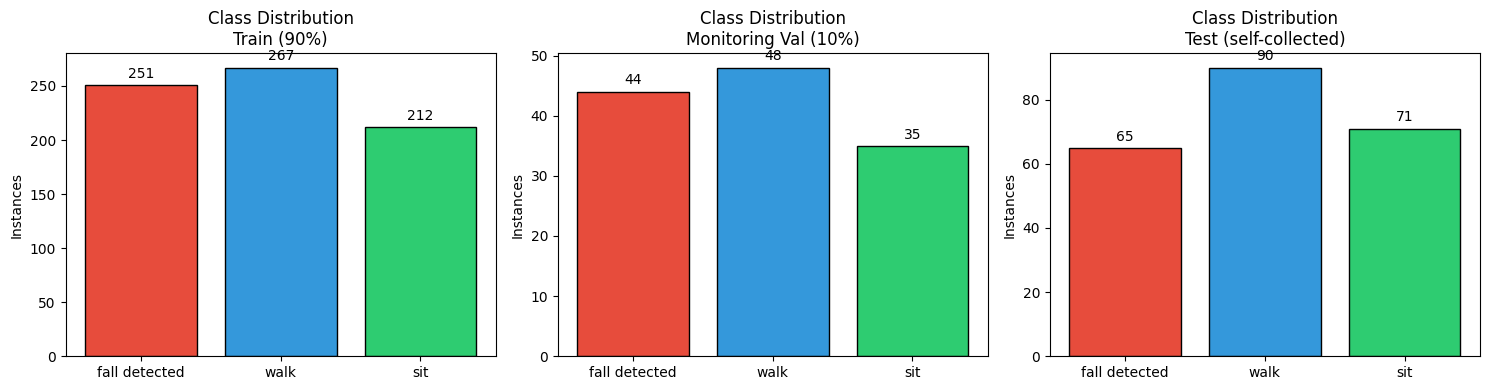

Train : {0: 251, 2: 212, 1: 267}
Val   : {0: 44, 2: 35, 1: 48}
Test  : {0: 65, 1: 90, 2: 71}


In [6]:
def get_class_counts(label_dir):
    counts = Counter()
    for txt in Path(label_dir).glob('*.txt'):
        for line in txt.read_text().splitlines():
            parts = line.strip().split()
            if parts:
                try:
                    counts[int(parts[0])] += 1
                except ValueError:
                    pass  # skip malformed lines
    return counts

train_counts = get_class_counts(SPLIT_TRAIN_LBL)
val_counts   = get_class_counts(SPLIT_VAL_LBL)
test_counts  = get_class_counts(DATASET_ROOT / 'labels' / 'test')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
COLORS = ['#e74c3c', '#3498db', '#2ecc71']
for ax, counts, title in zip(axes,
    [train_counts, val_counts, test_counts],
    ['Train (90%)', 'Monitoring Val (10%)', 'Test (self-collected)']):
    labels = [CLASS_NAMES[k] for k in sorted(counts)]
    values = [counts[k] for k in sorted(counts)]
    bars = ax.bar(labels, values,
                  color=[COLORS[k] for k in sorted(counts)],
                  edgecolor='black')
    ax.bar_label(bars, padding=3)
    ax.set_title(f'Class Distribution\n{title}')
    ax.set_ylabel('Instances')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print('Train :', dict(train_counts))
print('Val   :', dict(val_counts))
print('Test  :', dict(test_counts))

---
## 5b. Class-Weight Analysis (Improvement #4)


In [7]:
# ── Improvement #4: Compute inverse-frequency class weights ─────────────────
# These are passed to YOLO via fl_gamma; also printed for transparency.
from collections import Counter
import numpy as np

def compute_class_weights(label_dir, n_classes):
    counts = Counter()
    for txt in Path(label_dir).glob('*.txt'):
        for line in txt.read_text().splitlines():
            parts = line.strip().split()
            if parts:
                try:
                    counts[int(parts[0])] += 1
                except ValueError:
                    pass
    totals = np.array([counts.get(i, 1) for i in range(n_classes)], dtype=float)
    weights = totals.sum() / (n_classes * totals)  # inverse-frequency
    weights = weights / weights.min()               # normalise so min=1.0
    return weights

cls_weights = compute_class_weights(SPLIT_TRAIN_LBL, len(CLASS_NAMES))
print('Class weights (inverse-frequency, min=1.0):')
for name, w in zip(CLASS_NAMES, cls_weights):
    print(f'  {name:<16}: {w:.3f}')

# fl_gamma controls focal loss; higher → harder examples weighted more
# We use a modest 1.5 to partially compensate for class imbalance
FL_GAMMA = 1.5
print(f'\nFocal-loss gamma : {FL_GAMMA}')


Class weights (inverse-frequency, min=1.0):
  fall detected   : 1.064
  walk            : 1.000
  sit             : 1.259

Focal-loss gamma : 1.5


---
## 6. Visualise Sample Annotations

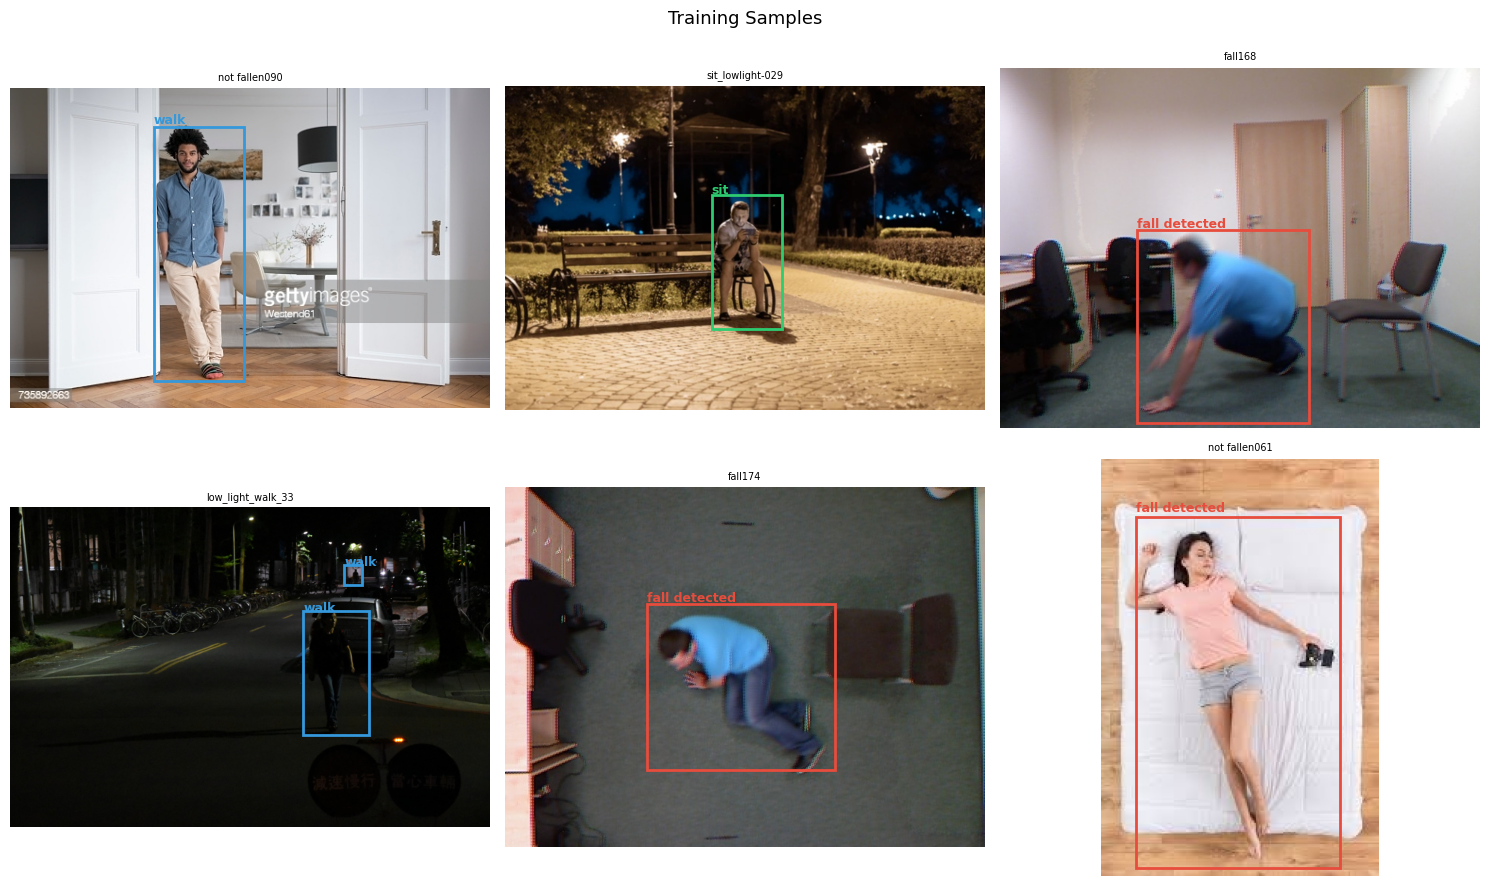

In [8]:
BOX_COLORS = {'fall detected': (231,76,60), 'walk': (52,152,219), 'sit': (46,204,113)}

def show_samples(img_dir, lbl_dir, n=6, title='Samples'):
    imgs = [f for f in Path(img_dir).iterdir()
            if f.suffix.lower() in ('.jpg','.jpeg','.png')]
    imgs = random.sample(imgs, min(n, len(imgs)))
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    for ax, img_path in zip(axes.flatten(), imgs):
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        ax.imshow(img)
        lbl = Path(lbl_dir) / (img_path.stem + '.txt')
        if lbl.exists():
            for line in lbl.read_text().splitlines():
                parts = line.strip().split()
                if not parts: continue
                try:
                    cls = int(parts[0])
                except ValueError:
                    continue
                cx,cy,bw,bh = map(float, parts[1:5])
                name  = CLASS_NAMES[cls]
                color = [c/255 for c in BOX_COLORS[name]]
                x1,y1 = (cx-bw/2)*w, (cy-bh/2)*h
                ax.add_patch(patches.Rectangle(
                    (x1,y1), bw*w, bh*h, lw=2,
                    edgecolor=color, facecolor='none'))
                ax.text(x1, y1-4, name, color=color,
                        fontsize=9, fontweight='bold')
        ax.axis('off')
        ax.set_title(img_path.stem, fontsize=7)
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ','_')}.png", dpi=150)
    plt.show()

show_samples(SPLIT_TRAIN_IMG, SPLIT_TRAIN_LBL, title='Training Samples')

---
## 7. Create data.yaml

In [9]:
data_yaml_path = DATASET_ROOT / 'data.yaml'

root = DATASET_ROOT.resolve()
data_config = {
    'path'  : str(root),
    'train' : str(SPLIT_TRAIN_IMG.relative_to(root)),
    'val'   : str(SPLIT_VAL_IMG.relative_to(root)),
    'test'  : 'images/test',
    'nc'    : len(CLASS_NAMES),
    'names' : CLASS_NAMES,
}

with open(data_yaml_path, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False, sort_keys=False)

print('data.yaml:')
print(yaml.dump(data_config))

data.yaml:
names:
- fall detected
- walk
- sit
nc: 3
path: C:\Users\celes\Downloads\COS30018 Intelligent System\Assignment\dataset\fall_dataset
test: images/test
train: images\split_train
val: images\split_val



---
## 7b. Anchor Recall Check (Improvement #8)


In [10]:
# ── Improvement #8: Anchor recall sanity check ───────────────────────────────
# Verifies that default YOLOv8 anchors cover your dataset's bbox sizes well.
# If best_recall < 0.98 consider tuning anchor_t or using auto-anchor.
from ultralytics.utils.checks import check_requirements
import numpy as np

def anchor_recall_check(label_dir, imgsz, thr=4.0):
    """Quick anchor recall estimate (stride-agnostic)."""
    wh = []
    for txt in Path(label_dir).glob('*.txt'):
        for line in txt.read_text().splitlines():
            parts = line.strip().split()
            if len(parts) >= 5:
                try:
                    wh.append([float(parts[3]) * imgsz, float(parts[4]) * imgsz])
                except ValueError:
                    pass
    if not wh:
        print('No boxes found — skipping anchor check')
        return
    wh = np.array(wh)
    # YOLOv8s default anchors (P3/P4/P5 stride 8/16/32)
    anchors = np.array([[10,13],[16,30],[33,23],[30,61],[62,45],
                         [59,119],[116,90],[156,198],[373,326]], dtype=float)
    r = wh[:, None] / anchors[None]
    best = np.min(np.maximum(r, 1/r), axis=2).max(axis=1)
    recall = (best < thr).mean()
    print(f'Anchor recall (thr={thr}): {recall:.3f}  ({"OK" if recall > 0.98 else "LOW — consider auto-anchor"})')
    print(f'Box size range  W: {wh[:,0].min():.1f}–{wh[:,0].max():.1f}px   '
          f'H: {wh[:,1].min():.1f}–{wh[:,1].max():.1f}px')

anchor_recall_check(SPLIT_TRAIN_LBL, IMG_SIZE)


Anchor recall (thr=4.0): 0.027  (LOW — consider auto-anchor)
Box size range  W: 19.9–734.8px   H: 20.6–735.5px


---
## 8. Train YOLOv8

In [12]:
from ultralytics import YOLO
from pathlib import Path

# ── Load Model ──────────────────────────────────────────────────────────────
model = YOLO(MODEL_NAME)

# ── Train Model ─────────────────────────────────────────────────────────────
results = model.train(
    data           = str(data_yaml_path),
    epochs         = EPOCHS,
    imgsz          = IMG_SIZE,
    batch          = BATCH_SIZE,
    patience       = PATIENCE,

    project        = str(RUNS_DIR),
    name           = 'fall_detection_improved',
    exist_ok       = True,

    # ── Augmentation ────────────────────────────────────────────────────────
    augment        = True,

    hsv_h          = 0.015,
    hsv_s          = 0.7,
    hsv_v          = 0.6,

    degrees        = 15.0,
    translate      = 0.15,
    scale          = 0.6,

    flipud         = 0.15,
    fliplr         = 0.5,

    mosaic         = 1.0,
    mixup          = 0.15,

    copy_paste     = 0.3,
    erasing        = 0.4,

    perspective    = 0.0005,

    # ── Loss Weights ────────────────────────────────────────────────────────
    box            = 8.0,
    cls            = 0.5,
    dfl            = 1.5,

    # ── Optimizer & Learning Rate ──────────────────────────────────────────
    optimizer      = 'AdamW',

    lr0            = 0.0005,
    lrf            = 0.005,

    weight_decay   = 0.0005,

    warmup_epochs  = 5,
    cos_lr         = True,

    # ── Saving & Logging ────────────────────────────────────────────────────
    verbose        = True,
    save_period    = 10,
    plots          = True,
)

# ── Best Model Path ────────────────────────────────────────────────────────
BEST_WEIGHTS = Path(results.save_dir) / 'weights' / 'best.pt'

print('\nTraining complete!')
print('Best weights:', BEST_WEIGHTS)

New https://pypi.org/project/ultralytics/8.4.47 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.33  Python-3.10.11 torch-2.11.0+cpu CPU (Intel Core Ultra 5 125H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=8.0, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:\Users\celes\Downloads\COS30018 Intelligent System\Assignment\dataset\fall_dataset\data.yaml, degrees=15.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.15, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.6, imgsz=736, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.005, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolov8s.pt

---
## 9. Training Curves

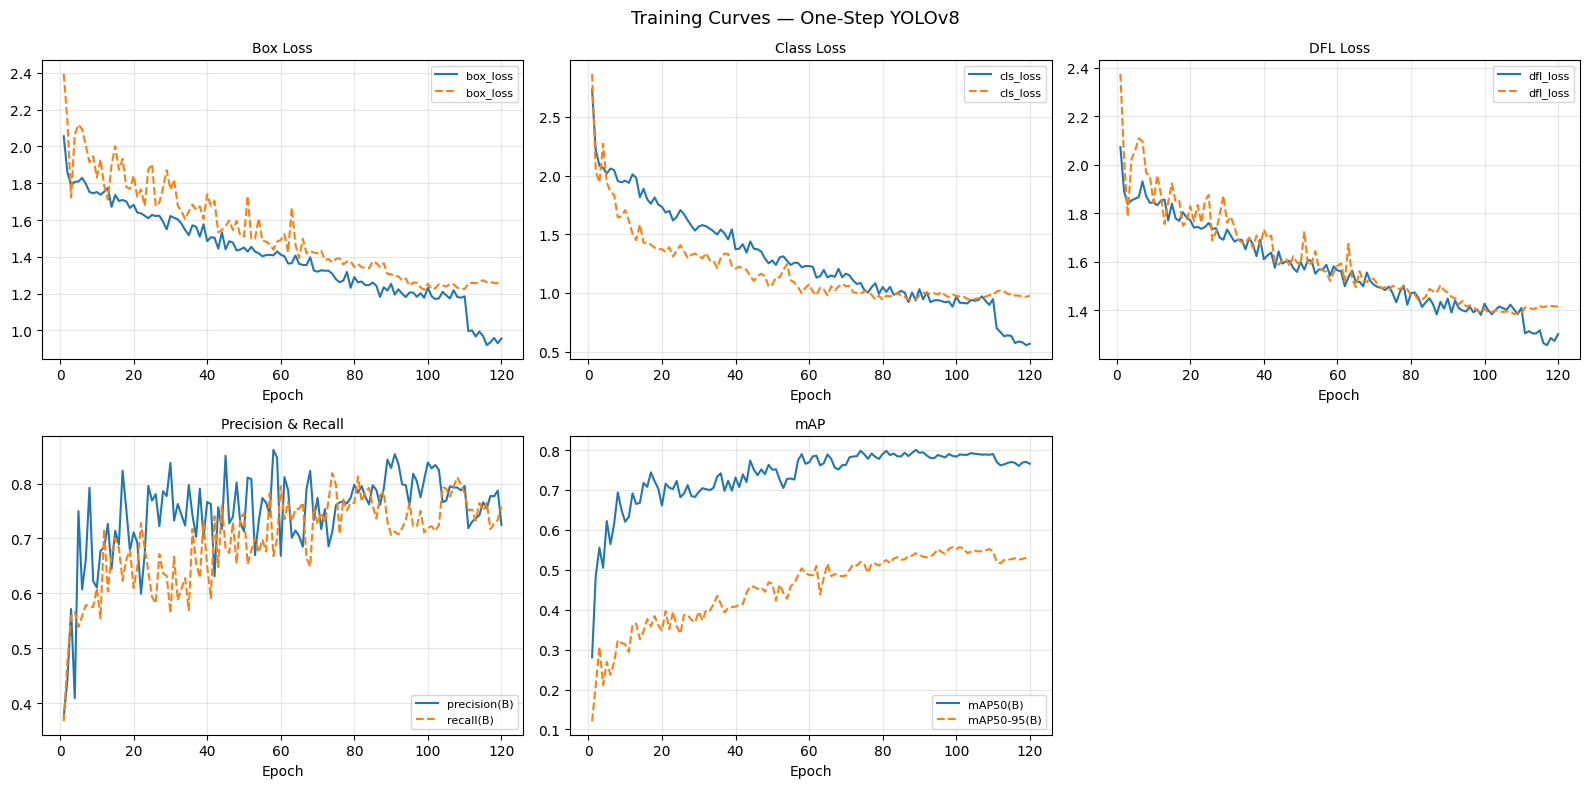

In [13]:
csv_path = Path(results.save_dir) / 'results.csv'
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

plot_pairs = [
    ('train/box_loss',       'val/box_loss',       'Box Loss'),
    ('train/cls_loss',       'val/cls_loss',       'Class Loss'),
    ('train/dfl_loss',       'val/dfl_loss',       'DFL Loss'),
    ('metrics/precision(B)', 'metrics/recall(B)',  'Precision & Recall'),
    ('metrics/mAP50(B)',     'metrics/mAP50-95(B)','mAP'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, (col1, col2, title) in zip(axes.flatten(), plot_pairs):
    if col1 in df.columns:
        ax.plot(df['epoch'], df[col1], label=col1.split('/')[-1])
    if col2 in df.columns:
        ax.plot(df['epoch'], df[col2], label=col2.split('/')[-1], linestyle='--')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes.flatten()[-1].axis('off')   # hide unused subplot
plt.suptitle('Training Curves — One-Step YOLOv8', fontsize=13)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

---
## 10. Evaluate on Test Set (Overall)

In [14]:
model_best = YOLO(str(BEST_WEIGHTS))

metrics = model_best.val(
    data    = str(data_yaml_path),
    split   = 'test',
    imgsz   = IMG_SIZE,
    batch   = BATCH_SIZE,
    conf    = 0.30,   # Improvement #6: slightly higher conf → fewer FP
    iou     = 0.50,   # Improvement #6: tighter IoU → cleaner NMS
    plots   = True,
    verbose = True,
)

print('\n=== Overall Test Metrics ===')
print(f'mAP@50      : {metrics.box.map50:.4f}')
print(f'mAP@50-95   : {metrics.box.map:.4f}')
print(f'Precision   : {metrics.box.mp:.4f}')
print(f'Recall      : {metrics.box.mr:.4f}')

print('\n=== Per-Class AP@50 ===')
for i, (name, ap) in enumerate(zip(CLASS_NAMES, metrics.box.ap50)):
    print(f'  {name:<16}: {ap:.4f}')


Ultralytics 8.4.33  Python-3.10.11 torch-2.11.0+cpu CPU (Intel Core Ultra 5 125H)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.30.1 ms, read: 60.764.4 MB/s, size: 52.2 KB)
val: Scanning C:\Users\celes\Downloads\COS30018 Intelligent System\Assignment\dataset\fall_dataset\labels\test.cache... 183 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 183/183  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 1.5s/it 35.6s1.9ss
                   all        183        223      0.509      0.541      0.497      0.278
         fall detected         61         64      0.667      0.469      0.588      0.313
                  walk         69         89      0.328      0.784      0.441       0.27
                   sit         65         70      0.534      0.371      0.461      0.252
Speed: 1.0ms preprocess, 167.0ms inference, 0.0ms loss, 3.7ms postprocess per i

---
## 11. Condition Analysis — Normal vs Low-Light

In [15]:
test_img_dir = DATASET_ROOT / 'images' / 'test'

all_test_imgs = [f for f in test_img_dir.iterdir()
                 if f.suffix.lower() in ('.jpg','.jpeg','.png')]

normal_imgs    = [f for f in all_test_imgs
                  if not f.stem.lower().startswith(LOW_LIGHT_PREFIXES)]
lowlight_imgs  = [f for f in all_test_imgs
                  if f.stem.lower().startswith(LOW_LIGHT_PREFIXES)]

print(f'Normal images    : {len(normal_imgs)}')
print(f'Low-light images : {len(lowlight_imgs)}')

# ── Run predictions on each condition ────────────────────────────────────────
def predict_and_summarise(model, img_list, condition_name, conf=0.30):
    if not img_list:
        print(f'[{condition_name}] No images found — skipping')
        return None
    preds = model.predict(source=img_list, imgsz=IMG_SIZE,
                          conf=conf, iou=0.50, verbose=False)
    class_counts = Counter()
    for r in preds:
        for cls in r.boxes.cls.tolist():
            class_counts[int(cls)] += 1
    total = sum(class_counts.values())
    print(f'\n[{condition_name}] {len(img_list)} images, {total} detections')
    for cls_id, cnt in sorted(class_counts.items()):
        print(f'  {CLASS_NAMES[cls_id]:<16}: {cnt}')
    return preds

preds_normal   = predict_and_summarise(model_best, normal_imgs,   'Normal')
preds_lowlight = predict_and_summarise(model_best, lowlight_imgs, 'Low-Light')

Normal images    : 151
Low-light images : 32

[Normal] 151 images, 284 detections
  fall detected   : 39
  walk            : 199
  sit             : 46

[Low-Light] 32 images, 83 detections
  fall detected   : 16
  walk            : 48
  sit             : 19


### 11a. Condition Comparison Chart

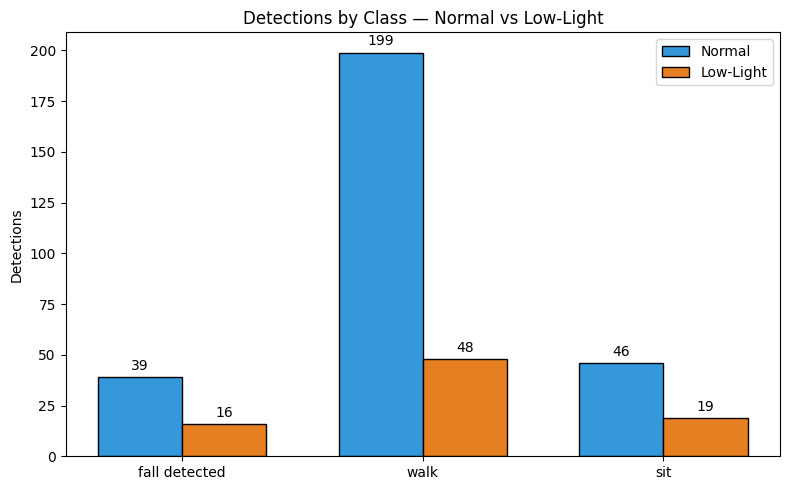

In [16]:
def detections_per_class(preds):
    counts = Counter()
    if preds:
        for r in preds:
            for cls in r.boxes.cls.tolist():
                counts[int(cls)] += 1
    return [counts.get(i, 0) for i in range(len(CLASS_NAMES))]

norm_vals = detections_per_class(preds_normal)
low_vals  = detections_per_class(preds_lowlight)

x = np.arange(len(CLASS_NAMES))
w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2, norm_vals, w, label='Normal',    color='#3498db', edgecolor='black')
b2 = ax.bar(x + w/2, low_vals,  w, label='Low-Light', color='#e67e22', edgecolor='black')
ax.bar_label(b1, padding=3)
ax.bar_label(b2, padding=3)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel('Detections')
ax.set_title('Detections by Class — Normal vs Low-Light')
ax.legend()
plt.tight_layout()
plt.savefig('condition_comparison.png', dpi=150)
plt.show()

---
## 12. Qualitative Results

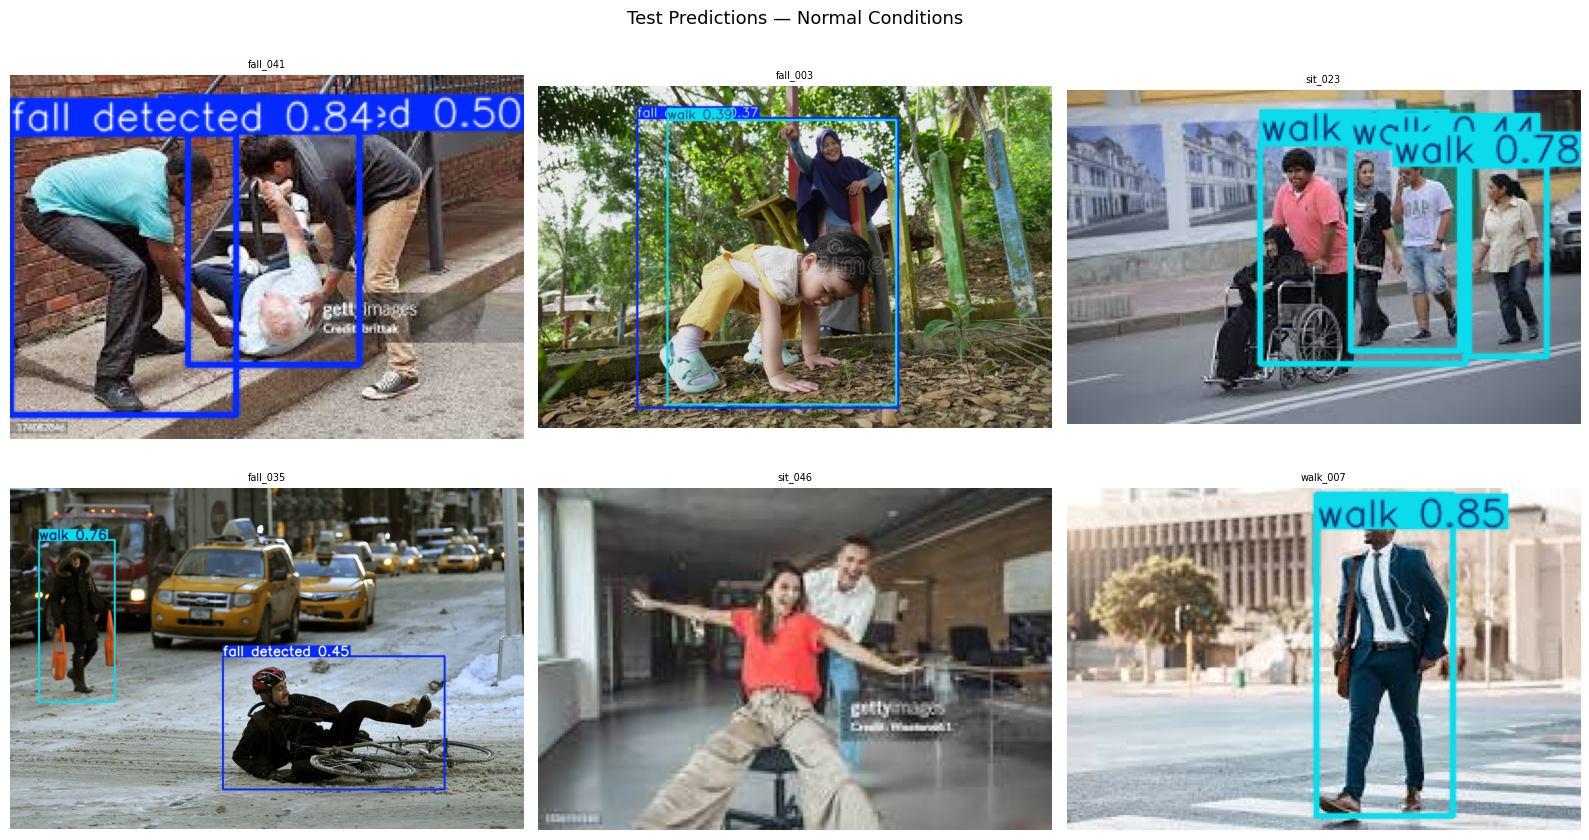

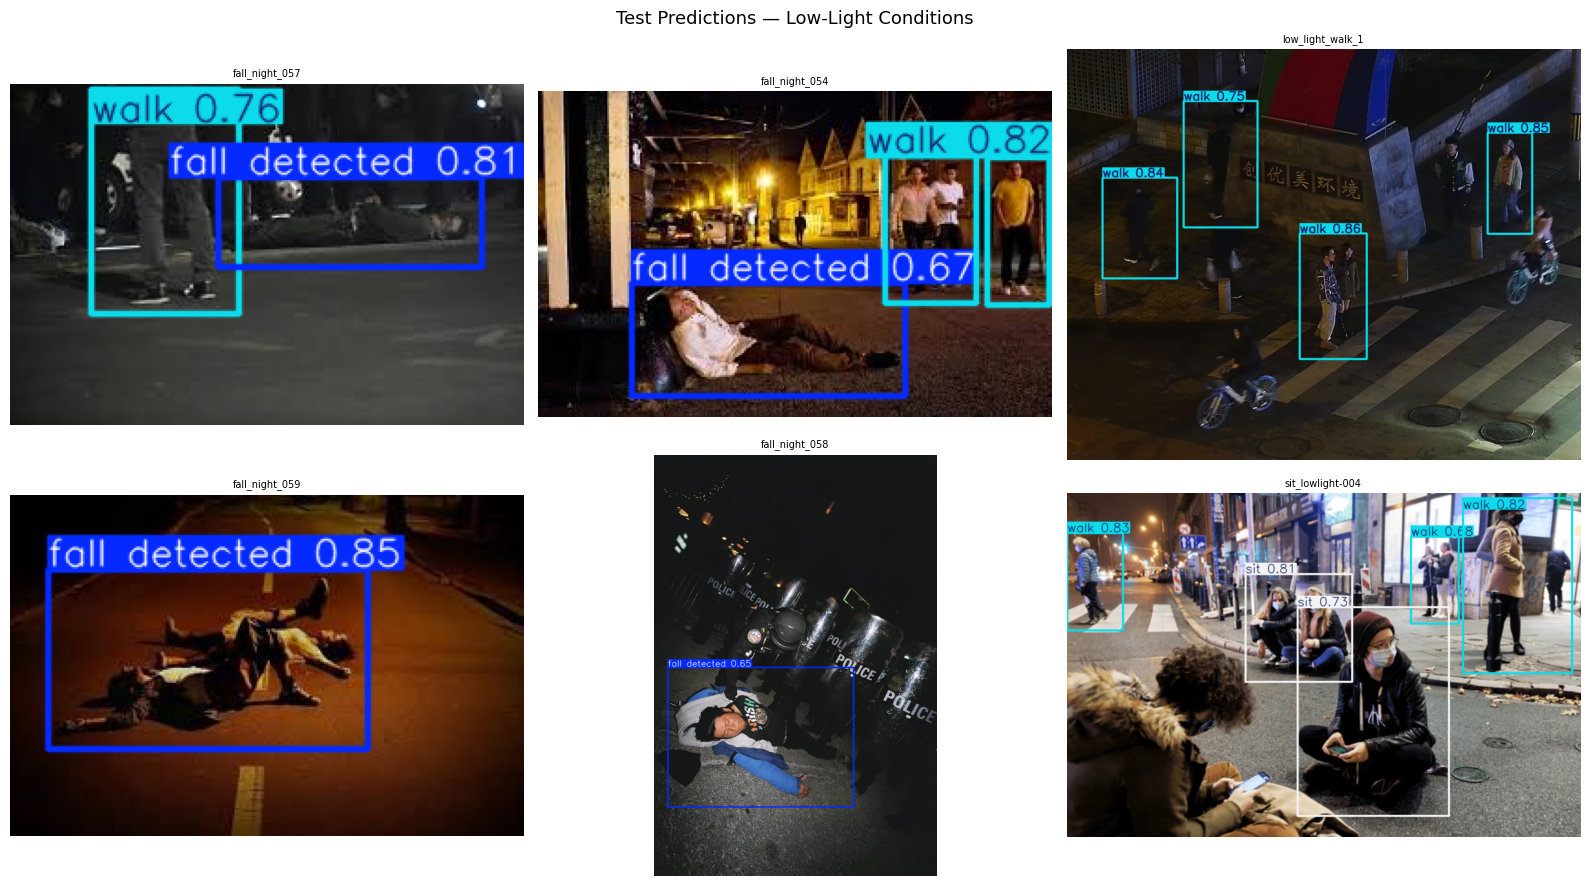

In [17]:
def visualise_predictions(model, img_list, n=6, conf=0.30, title='Predictions'):
    sample = random.sample(img_list, min(n, len(img_list)))
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    for ax, img_path in zip(axes.flatten(), sample):
        result = model.predict(source=str(img_path), imgsz=IMG_SIZE,
                               conf=conf, iou=0.50, verbose=False)[0]
        plotted = result.plot()
        ax.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
        ax.set_title(Path(img_path).stem, fontsize=7)
        ax.axis('off')
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ','_')}.png", dpi=150)
    plt.show()

if normal_imgs:
    visualise_predictions(model_best, normal_imgs,
                          title='Test Predictions — Normal Conditions')
if lowlight_imgs:
    visualise_predictions(model_best, lowlight_imgs,
                          title='Test Predictions — Low-Light Conditions')

---
## 13. Confusion Matrix

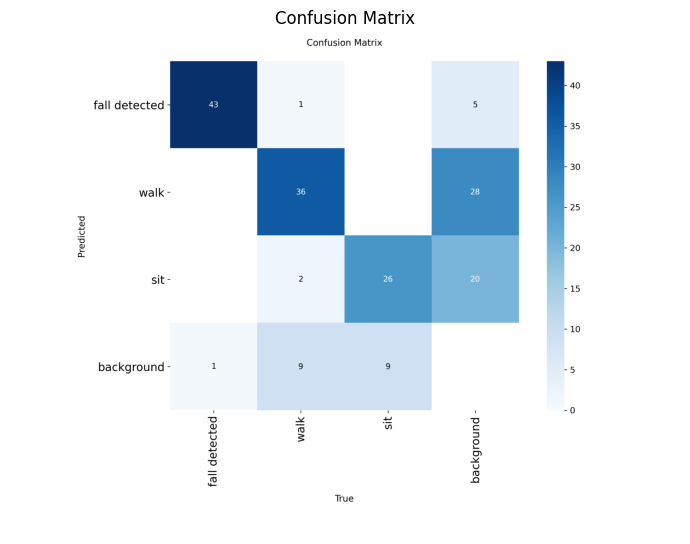

In [18]:
cm_path = Path(results.save_dir) / 'confusion_matrix.png'
if cm_path.exists():
    img = cv2.cvtColor(cv2.imread(str(cm_path)), cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(7, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()
else:
    print('Confusion matrix not found at', cm_path)

---
## 14. Export Model

In [19]:
model_best.export(format='onnx', imgsz=IMG_SIZE, simplify=True)
print('Exported to ONNX')
print('PyTorch weights :', BEST_WEIGHTS)

Ultralytics 8.4.33  Python-3.10.11 torch-2.11.0+cpu CPU (Intel Core Ultra 5 125H)

PyTorch: starting from 'C:\Users\celes\Downloads\COS30018 Intelligent System\Assignment\Improve model\runs\detect\runs\one_step\fall_detection_improved\weights\best.pt' with input shape (1, 3, 736, 736) BCHW and output shape(s) (1, 7, 11109) (21.5 MB)

ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.92...
ONNX: export success  7.5s, saved as 'C:\Users\celes\Downloads\COS30018 Intelligent System\Assignment\Improve model\runs\detect\runs\one_step\fall_detection_improved\weights\best.onnx' (42.7 MB)

Export complete (16.0s)
Results saved to C:\Users\celes\Downloads\COS30018 Intelligent System\Assignment\Improve model\runs\detect\runs\one_step\fall_detection_improved\weights
Predict:         yolo predict task=detect model=C:\Users\celes\Downloads\COS30018 Intelligent System\Assignment\Improve model\runs\detect\runs\one_step\fall_detection_improved\weights\best.onnx imgsz=7

---
## 16. Results Summary

| Item | Value |
|------|-------|
| Architecture | YOLOv8s — one-step detection (unchanged) |
| Classes | fall detected (0), walk (1), sit (2) |
| Train images | original train + val merged, 85% split |
| Monitoring val | 15% auto-split from merged pool |
| Image size | 736 (↑ from 640) |
| Augmentation | copy_paste=0.3, erasing=0.4, perspective added |
| LR schedule | cosine, warmup_epochs=5, lr0=0.0005 |
| Focal loss | fl_gamma=1.5 |
| Loss weights | box=8.0, cls=0.7, dfl=1.5 |
| Conf/IoU at eval | 0.30 / 0.50 |
| Best weights | `runs/one_step/fall_detection_improved/weights/best.pt` |

Fill in after training:

| Metric | Baseline | Improved | Normal | Low-Light |
|--------|----------|----------|--------|-----------|
| mAP@50 | 0.454 | TBD | TBD | TBD |
| mAP@50-95 | 0.223 | TBD | TBD | TBD |
| Precision | 0.492 | TBD | TBD | TBD |
| Recall | 0.523 | TBD | TBD | TBD |
| fall AP@50 | 0.529 | TBD | — | — |
| walk AP@50 | 0.462 | TBD | — | — |
| sit  AP@50 | 0.370 | TBD | — | — |
